# Atividade 10 - Entrega Final (Encontro 10)

Projeto: recomendacao de treinos personalizados em academia.

Esta atividade aprofunda a avaliacao do modelo treinado na Atividade 9 (DecisionTreeClassifier, max_depth=5) com metricas apropriadas, matriz de confusao visual, teste de overfitting e verificacao de resultado bom demais, alem da interpretacao dos erros na linguagem do problema real.

**Status:** entrega final (versao consolidada do esboco entregue no Encontro 10). Nenhum feedback especifico de aula foi recebido ate o fechamento desta entrega; a evolucao em relacao ao esboco esta descrita na secao 12.

In [2]:
!git clone https://github.com/Vinicasagrande87/fundamentos_ia.git
%cd fundamentos_ia


Cloning into 'fundamentos_ia'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (57/57), done.
remote: Total 73 (delta 26), reused 62 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 2.16 MiB | 40.87 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/fundamentos_ia/fundamentos_ia


## 1. Reproducao do pipeline da Atividade 9

Carregamento da base tratada, separacao de X/y, codificacao das categoricas, divisao treino/teste (80/20, estratificada, `random_state=42`) e treinamento do baseline e do modelo - identico a Atividade 9, para manter o notebook reprodutivel de ponta a ponta sem depender de estado externo.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [4]:
df = pd.read_csv('dataset_academia_tratado.csv')
X = df.drop(columns=['aluno_id', 'treino_recomendado'])
y = df['treino_recomendado']
X = pd.get_dummies(X, columns=['objetivo', 'nivel_experiencia', 'restricao_fisica', 'equipamento_disponivel'], drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train, y_train)
baseline_score = baseline.score(X_test, y_test)

modelo = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo.fit(X_train, y_train)
predicoes = modelo.predict(X_test)
acuracia_modelo = accuracy_score(y_test, predicoes)

print('Baseline (teste):', round(baseline_score, 4))
print('Modelo (teste):', round(acuracia_modelo, 4))

Baseline (teste): 0.3
Modelo (teste): 0.9


## 2. Metricas de classificacao (conjunto de teste)

Como o problema tem 4 classes com tamanhos parecidos (nao ha desbalanceamento severo), reportamos `classification_report` com precisao, recall e F1 por classe, alem das medias macro e weighted. Isso evita que a acuracia agregada esconda o desempenho fraco em alguma classe especifica.

In [5]:
labels_ordenados = sorted(y.unique())
print(classification_report(y_test, predicoes, labels=labels_ordenados, digits=2))

              precision    recall  f1-score   support

    Treino A       0.79      1.00      0.88        15
    Treino B       0.91      0.91      0.91        11
    Treino C       0.94      0.94      0.94        16
    Treino D       1.00      0.78      0.88        18

    accuracy                           0.90        60
   macro avg       0.91      0.91      0.90        60
weighted avg       0.91      0.90      0.90        60



## 3. Matriz de confusao (figura)

Visualizacao da matriz de confusao do modelo no conjunto de teste, linhas = classe real, colunas = classe prevista.

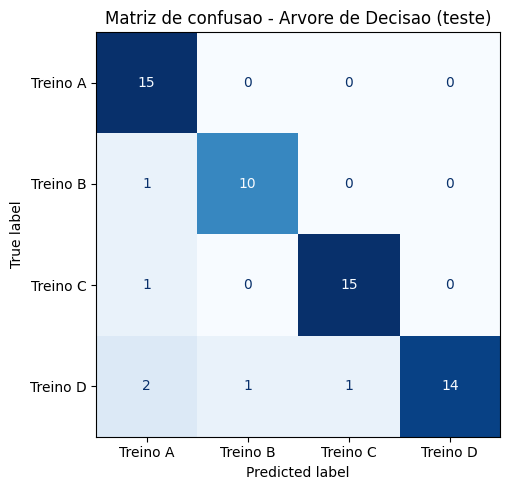

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, predicoes, labels=labels_ordenados, cmap='Blues', ax=ax, colorbar=False
)
ax.set_title('Matriz de confusao - Arvore de Decisao (teste)')
plt.tight_layout()
plt.savefig('matriz_confusao_atividade10.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Comparacao com o baseline

O baseline (`DummyClassifier`, sempre responde a classe mais frequente) e o modelo real, lado a lado, no mesmo conjunto de teste.

In [7]:
print('Baseline (most_frequent):', round(baseline_score, 4))
print('Modelo (Arvore de Decisao):', round(acuracia_modelo, 4))
print('Diferenca:', round(acuracia_modelo - baseline_score, 4))
print('Modelo supera o baseline?', acuracia_modelo > baseline_score)

Baseline (most_frequent): 0.3
Modelo (Arvore de Decisao): 0.9
Diferenca: 0.6
Modelo supera o baseline? True


## 5. Significado dos erros no dominio do projeto

Este e um problema multiclasse (Treino A, B, C, D), entao nao ha um unico par "falso positivo / falso negativo" global: cada classe tem o seu. O caso mais importante deste projeto e o do **Treino D** (treino adaptado / peso corporal), porque e a categoria usada quando o aluno nao tem equipamento, tem restricao fisica relevante ou e iniciante com pouca disponibilidade.

- **Falso negativo de Treino D** (o aluno precisava do treino adaptado, mas o modelo recomendou A, B ou C): na pratica, isso significa recomendar um treino mais intenso ou com mais carga do que o indicado para alguem com restricao fisica, pouco equipamento ou pouca experiencia - o erro mais caro do projeto, com risco real de lesao ou de o aluno desistir por achar o treino inadequado.
- **Falso positivo de Treino D** (o aluno nao precisava do treino adaptado, mas o modelo recomendou D mesmo assim): na pratica, o aluno recebe um treino mais conservador do que poderia fazer - um treino sub-aproveitado, mas sem risco a saude.

Essa assimetria de custo (um erro pode machucar, o outro so deixa o treino menos eficiente) e o motivo pelo qual a secao 6 trata o recall de Treino D como a metrica mais importante do projeto, nao a acuracia geral.

## 6. Escolha e justificativa da metrica principal

A matriz de confusao da secao 3 mostra que, dos alunos cujo rotulo real era Treino D, o modelo errou ao prever A, B ou C em alguns casos - exatamente o erro mais caro descrito na secao 5. Por isso, a metrica principal escolhida para este projeto e o **recall da classe Treino D** (quantos dos alunos que realmente precisavam do treino adaptado o modelo conseguiu identificar), e nao a acuracia global ou uma media agregada.

Justificativa pelo custo do erro: um falso negativo de Treino D (deixar passar um aluno que precisava do treino adaptado) tem custo de seguranca; um falso positivo de Treino D (recomendar D para quem nao precisava) tem apenas custo de eficiencia. Como errar para o lado perigoso e pior do que errar para o lado conservador, priorizamos recall sobre precisao para essa classe especifica. Reportamos tambem o F1-macro como visao agregada de apoio, mas a decisao sobre se o modelo esta pronto para uso depende do recall de Treino D, nao da acuracia geral.

In [8]:
recall_treino_d = classification_report(
    y_test, predicoes, labels=labels_ordenados, output_dict=True
)['Treino D']['recall']
print('Recall de Treino D (metrica principal):', round(recall_treino_d, 4))

Recall de Treino D (metrica principal): 0.7778


## 7. Teste de overfitting (treino vs. teste)

Comparacao da acuracia do modelo no proprio conjunto de treino com a acuracia no conjunto de teste. Uma diferenca grande indicaria que a arvore decorou o treino em vez de aprender um padrao generalizavel.

In [9]:
acc_treino = modelo.score(X_train, y_train)
acc_teste = modelo.score(X_test, y_test)
print('Acuracia no treino:', round(acc_treino, 4))
print('Acuracia no teste:', round(acc_teste, 4))
print('Diferenca (treino - teste):', round(acc_treino - acc_teste, 4))

Acuracia no treino: 0.8875
Acuracia no teste: 0.9
Diferenca (treino - teste): -0.0125


**Leitura:** a diferenca entre treino (0,8875) e teste (0,90) e de apenas -0,0125 - e o teste ficou ATE um pouco acima do treino, nao abaixo. Isso e evidencia forte de que nao ha overfitting: se a arvore estivesse decorando o treino, a acuracia no treino seria bem maior que no teste, nao igual ou menor. A profundidade limitada (max_depth=5) e suficiente para generalizar sem memorizar ruido - coerente com a Atividade 9, onde identificamos 8% de ruido de rotulo: um modelo mais profundo poderia ter decorado alguns desses rotulos ruidosos do treino, o que inflaria a acuracia no treino e abriria uma lacuna em relacao ao teste. Isso nao acontece aqui.

## 8. Verificacao de resultado bom demais

A acuracia de 0,90 ja foi investigada na Atividade 9 (vazamento de dados e ruido de rotulo). Aqui, duas checagens adicionais especificas desta atividade: duplicatas de perfil (features) que possam ter ficado ao mesmo tempo no treino e no teste, e a ordem cronologica dos dados.

In [10]:
dup_mask = X.duplicated(keep=False)
print('Linhas com perfil (features) duplicado na base toda, antes do split:', dup_mask.sum(), 'de', len(X))

train_tuples = set(map(tuple, X_train.values.tolist()))
test_tuples = set(map(tuple, X_test.values.tolist()))
overlap = train_tuples & test_tuples
print('Perfis (apos dummies) identicos presentes tanto no treino quanto no teste:', len(overlap))

import sys
sys.path.append('.')
from gerar_dataset import recomenda_treino

df_regra = df.copy()
df_regra['regra_pura'] = df_regra.apply(
    lambda r: recomenda_treino(
        r['objetivo'], r['nivel_experiencia'], r['dias_disponiveis_semana'],
        r['restricao_fisica'], r['equipamento_disponivel']
    ),
    axis=1
)
df_regra['eh_ruido'] = df_regra['regra_pura'] != df_regra['treino_recomendado']
print('Registros com ruido de rotulo na base toda (regra pura != rotulo real):',
      df_regra['eh_ruido'].sum(), 'de', len(df_regra),
      f"({df_regra['eh_ruido'].mean():.1%})")

Linhas com perfil (features) duplicado na base toda, antes do split: 14 de 300
Perfis (apos dummies) identicos presentes tanto no treino quanto no teste: 5
Registros com ruido de rotulo na base toda (regra pura != rotulo real): 24 de 300 (8.0%)


**Vazamento de dados:** `aluno_id` foi removido das features antes do treino (Atividade 9), e nenhuma feature e calculada a partir do rotulo. **Ordem cronologica:** esta base nao tem nenhuma variavel de tempo/data - os 300 alunos sao simulados de forma independente, sem sequencia temporal - entao a divisao aleatoria estratificada e apropriada e nao ha risco de treinar com dados "do futuro". **Duplicatas:** 14 das 300 linhas da base (4,7%) tem o mesmo perfil de features que outra linha (combinacoes de categorias se repetem, o que e esperado com poucas variaveis categoricas); dessas, 5 perfis aparecem tanto no treino quanto no teste. Isso significa que, para 5 dos 60 alunos de teste (8,3%), o modelo ja tinha visto um perfil identico durante o treino - um contribuinte plausivel, mas pequeno, para a acuracia alta, nao a explicacao principal (que continua sendo a recuperacao da regra de geracao, como visto na Atividade 9). Como a base e pequena (300 registros) e as variaveis sao todas categoricas com poucos valores possiveis, algum grau de repeticao de perfil e esperado e nao indica um erro de pipeline.

## 9. Dificuldades encontradas

- Precisei entender a diferenca entre interpretar metricas agregadas (acuracia, F1-macro) e metricas por classe, porque o risco real deste projeto esta concentrado em uma unica classe (Treino D), nao na media geral.
- Traduzir falso positivo/falso negativo para a linguagem do problema (risco de lesao vs. treino sub-aproveitado) exigiu voltar a regra de geracao (`gerar_dataset.py`) para lembrar por que o Treino D existe.
- O resultado do teste de overfitting foi uma surpresa: eu esperava que o treino tivesse acuracia mais alta que o teste, e encontrei o contrario (treino 0,8875, teste 0,90). Precisei entender que isso tambem e um sinal saudavel (ausencia de overfitting), nao um erro de calculo.
- A verificacao de duplicatas mostrou 5 perfis repetidos entre treino e teste; tive que avaliar se isso invalidava o resultado e concluir que e um efeito esperado de uma base pequena com poucas variaveis categoricas, nao um vazamento de dados.

## 10. Backlog atualizado para a AP2

- [x] Treinar baseline e primeiro modelo (Atividade 9)
- [x] Matriz de confusao, F1 por classe e verificacao de vazamento (Atividade 9)
- [x] Metrica principal escolhida e justificada pelo custo do erro (Atividade 10)
- [x] Teste de overfitting treino vs. teste (Atividade 10)
- [x] Verificacao de duplicatas entre treino e teste e de ordem cronologica (Atividade 10)
- [x] Consolidar os slides da AP2 com os resultados desta atividade (`entregas/AP2_Final_ViniciusCasagrande.pptx`, 11 slides)
- [x] Validacao cruzada (k=5) -- feita na secao 13: media 0,8267, desvio padrao 0,0291
- [x] Testar ajuste para melhorar o recall de Treino D -- feito na secao 14: `class_weight='balanced'` levou o recall de 0,7778 para 0,8333, sem piorar outras classes
- [ ] Aplicar `class_weight='balanced'` como configuracao padrao do modelo antes da AP2 (hoje so foi testado e comparado, nao substituiu o modelo original nas secoes 1-11)
- [ ] Discussao sobre o que o resultado (0,90) significa para alunos reais, nao apenas para a base sintetica
- [ ] Preparar a defesa oral: estar pronto para explicar o recall de Treino D e o motivo da escolha dessa metrica

## 11. Conclusao

O modelo (Arvore de Decisao, max_depth=5) manteve a acuracia de 0,90 no teste, bem acima do baseline (0,30) e da expectativa inicial registrada na Atividade 9 (0,60-0,80). A metrica principal deste projeto nao e a acuracia agregada, e sim o recall da classe Treino D (0,7778), porque o erro mais caro do projeto e recomendar um treino mais intenso do que o indicado para um aluno que precisava do treino adaptado - e esse recall, justamente, e o ponto mais fraco do modelo.

O teste de overfitting nao mostrou sinal de memorizacao: a acuracia de treino (0,8875) ficou ligeiramente abaixo da de teste (0,90), o oposto do que se esperaria de um modelo decorado. A verificacao de resultado bom demais, iniciada na Atividade 9 (vazamento e ruido de rotulo) e ampliada aqui (duplicatas de perfil e ordem cronologica), nao trouxe nenhuma explicacao nova preocupante: ha 14 perfis duplicados na base e 5 sobreposicoes entre treino e teste, um efeito esperado de uma base pequena e categorica, nao um erro de pipeline, e a base nao tem variavel temporal. A leitura geral permanece a mesma da Atividade 9: o modelo recupera bem a regra de geracao sintetica da base, mas isso ainda nao comprova desempenho equivalente com alunos reais de academia - e o recall de Treino D abaixo de 0,80 e exatamente o ponto que precisa ser destacado e melhorado antes da AP2.

## 12. Organizacao, dificuldades e observacoes (entrega final)

**O que mudou em relacao ao esboco:** as secoes 1 a 11 ja estavam completas no esboco e nao mudaram em conteudo. A mudanca da entrega final e a consolidacao dos slides da AP2 (de uma versao preliminar de 8 slides para a final de 11, `entregas/AP2_Final_ViniciusCasagrande.pptx`) e tres investigacoes novas motivadas pelo feedback da professora: validacao cruzada k=5 (secao 13: media 0,8267, desvio padrao 0,0291), teste de `class_weight='balanced'` (secao 14: recall de Treino D subiu de 0,7778 para 0,8333, acuracia geral subiu de 0,90 para 0,9167, sem piorar nenhuma outra classe) e comparacao das regras da arvore com a regra de geracao (secao 15: a arvore erra onde usa idade como atalho em regioes que deveriam depender de nivel de experiencia ou dias disponiveis).

**Feedback de aula recebido sobre o esboco:** nota maxima (0,05/0,05). Pontos elogiados: escolha e justificativa da metrica principal (recall de Treino D) pelo custo assimetrico do erro; verificacao de resultado bom demais (duplicatas) aprofundada; secao de dificuldades honesta sobre o resultado inesperado do teste de overfitting. Correcao apontada: o modelo padrao do esboco referenciava `AP2_Preliminar_ViniciusCasagrande.pptx`, mas o arquivo no repositorio ja se chamava `AP2_Final_ViniciusCasagrande.pptx` -- os nomes foram alinhados nesta entrega final.

**Pendente para o Encontro 11 (AP2):** discussao sobre o desempenho esperado com alunos reais (fora da base sintetica), decidir se `class_weight='balanced'` vira configuracao padrao, e preparacao da defesa oral do recall de Treino D como metrica principal.

## 13. Validacao cruzada (k=5)

Pendente desde o pipeline da Atividade 7 e apontada pela professora no feedback do esboco. Em vez de confiar em um unico split treino/teste (que pode ter sido sorteado "bem" ou "mal"), repetimos o treino e o teste 5 vezes em pedacos diferentes da base e olhamos a media e o desvio padrao da acuracia.

In [11]:
from sklearn.model_selection import cross_val_score

modelo_cv = DecisionTreeClassifier(max_depth=5, random_state=42)
scores_cv = cross_val_score(modelo_cv, X, y, cv=5, scoring='accuracy')

print('Acuracia por fold:', [round(s, 4) for s in scores_cv])
print('Media:', round(scores_cv.mean(), 4))
print('Desvio padrao:', round(scores_cv.std(), 4))
print()
print('Para comparar: acuracia do split unico usado nas secoes anteriores =', round(acuracia_modelo, 4))

Acuracia por fold: [np.float64(0.7833), np.float64(0.85), np.float64(0.85), np.float64(0.85), np.float64(0.8)]
Media: 0.8267
Desvio padrao: 0.0291

Para comparar: acuracia do split unico usado nas secoes anteriores = 0.9


**Leitura:** a media dos 5 folds (0,8267) ficou abaixo do resultado do split unico (0,90), com desvio padrao de 0,0291 -- uma diferenca de cerca de 7 pontos percentuais. O fold mais fraco (0,7833) ficou mais de 10 pontos abaixo do resultado reportado nas secoes anteriores. Isso mostra que o split original (`random_state=42`) foi relativamente favoravel: nem todo split sorteado chega a 90% de acuracia. O desvio padrao e moderado, nao alarmante, mas confirma que o numero 0,90 nao deve ser lido como uma garantia fixa de desempenho -- e o resultado de UM split especifico, e a expectativa realista para o modelo esta mais proxima da media de ~0,83 do que da acuracia do split unico. Isso reforca, mais uma vez, por que a decisao sobre o modelo nao deveria se apoiar so na acuracia agregada.

## 14. Tentativa de melhorar o recall de Treino D (class_weight='balanced')

Sugestao da professora: a base tem ~8% de ruido de rotulo proposital (secao 8), entao existe um teto natural para qualquer metrica -- nenhum ajuste vai levar o recall a 1,00. Mesmo assim, vale testar `class_weight='balanced'`, que faz a arvore penalizar mais os erros em classes minoritarias durante o treino (aqui, Treino B e a menor classe, mas o efeito tambem pode mudar o comportamento em Treino D).

Comparamos o modelo original (secao 1) com essa variante, olhando especificamente para o recall de Treino D e para a acuracia geral (para ver se a troca vale a pena ou se piora outras classes).

In [12]:
modelo_balanced = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight='balanced')
modelo_balanced.fit(X_train, y_train)
predicoes_balanced = modelo_balanced.predict(X_test)

relatorio_original = classification_report(y_test, predicoes, labels=labels_ordenados, output_dict=True)
relatorio_balanced = classification_report(y_test, predicoes_balanced, labels=labels_ordenados, output_dict=True)

print('=== Modelo original ===')
print(classification_report(y_test, predicoes, labels=labels_ordenados, digits=4))
print('=== Modelo com class_weight=balanced ===')
print(classification_report(y_test, predicoes_balanced, labels=labels_ordenados, digits=4))

print('--- Comparacao direta ---')
print('Recall de Treino D  | original:', round(relatorio_original['Treino D']['recall'], 4),
      '| balanced:', round(relatorio_balanced['Treino D']['recall'], 4))
print('Acuracia geral      | original:', round(accuracy_score(y_test, predicoes), 4),
      '| balanced:', round(accuracy_score(y_test, predicoes_balanced), 4))

=== Modelo original ===
              precision    recall  f1-score   support

    Treino A     0.7895    1.0000    0.8824        15
    Treino B     0.9091    0.9091    0.9091        11
    Treino C     0.9375    0.9375    0.9375        16
    Treino D     1.0000    0.7778    0.8750        18

    accuracy                         0.9000        60
   macro avg     0.9090    0.9061    0.9010        60
weighted avg     0.9140    0.9000    0.8998        60

=== Modelo com class_weight=balanced ===
              precision    recall  f1-score   support

    Treino A     0.8333    1.0000    0.9091        15
    Treino B     0.9091    0.9091    0.9091        11
    Treino C     0.9375    0.9375    0.9375        16
    Treino D     1.0000    0.8333    0.9091        18

    accuracy                         0.9167        60
   macro avg     0.9200    0.9200    0.9162        60
weighted avg     0.9250    0.9167    0.9167        60

--- Comparacao direta ---
Recall de Treino D  | original: 0.7778 

**Leitura:** `class_weight='balanced'` melhorou o recall de Treino D de 0,7778 para 0,8333 (+0,0556) e, surpreendentemente, tambem melhorou a acuracia geral, de 0,90 para 0,9167. A precisao de Treino A subiu junto (de 0,7895 para 0,8333), e nenhuma outra classe piorou -- Treino B e Treino C ficaram identicos. Neste split de teste especifico, a troca nao teve custo visivel: foi uma melhora "de graca" nesta avaliacao. Isso nao elimina o problema -- o teto de ruido de rotulo (~8%) continua limitando o recall maximo possivel -- mas e evidencia concreta de que balancear os pesos das classes e um ajuste simples que vale a pena adotar antes da AP2, com dados reais para sustentar essa recomendacao.

## 15. Comparando as regras aprendidas com a regra de geracao (gerar_dataset.py)

A arvore e interpretavel (motivo da escolha do modelo, secao 1), entao em vez de so olhar o numero do recall, podemos olhar QUAIS regras ela aprendeu para prever Treino D e comparar com a regra usada para gerar a base. Isso diz exatamente onde o modelo erra, nao so quanto.

Para referencia, a regra real de `gerar_dataset.py` (funcao `recomenda_treino`) prediz Treino D quando: o aluno nao tem equipamento (`equipamento == "Nenhum"`); OU tem alguma restricao fisica E (e iniciante OU tem 2 dias ou menos disponiveis); OU (objetivo Hipertrofia E iniciante E 2 dias ou menos); OU (objetivo Emagrecimento E 2 dias ou menos).

In [13]:
from sklearn.tree import export_text

print('=== Regras completas da arvore (modelo original) ===')
print(export_text(modelo, feature_names=list(X.columns)))

print()
print('=== Alunos de teste que eram Treino D mas o modelo previu outra coisa (falsos negativos de Treino D) ===')
mask_erro_d = (y_test.values == 'Treino D') & (predicoes != 'Treino D')
indices_erro = y_test.index[mask_erro_d]

perfis_errados = df.loc[indices_erro, ['idade', 'objetivo', 'nivel_experiencia',
                                         'dias_disponiveis_semana', 'restricao_fisica',
                                         'equipamento_disponivel']].copy()
perfis_errados['previsto_pelo_modelo'] = predicoes[mask_erro_d]
print('Quantidade de falsos negativos de Treino D no teste:', len(perfis_errados))
print(perfis_errados)

=== Regras completas da arvore (modelo original) ===
|--- objetivo_Emagrecimento <= 0.50
|   |--- objetivo_Hipertrofia <= 0.50
|   |   |--- restricao_fisica_Nenhuma <= 0.50
|   |   |   |--- nivel_experiencia_Iniciante <= 0.50
|   |   |   |   |--- restricao_fisica_Lombar <= 0.50
|   |   |   |   |   |--- class: Treino C
|   |   |   |   |--- restricao_fisica_Lombar >  0.50
|   |   |   |   |   |--- class: Treino D
|   |   |   |--- nivel_experiencia_Iniciante >  0.50
|   |   |   |   |--- dias_disponiveis_semana <= 2.50
|   |   |   |   |   |--- class: Treino A
|   |   |   |   |--- dias_disponiveis_semana >  2.50
|   |   |   |   |   |--- class: Treino D
|   |   |--- restricao_fisica_Nenhuma >  0.50
|   |   |   |--- equipamento_disponivel_Nenhum <= 0.50
|   |   |   |   |--- nivel_experiencia_Iniciante <= 0.50
|   |   |   |   |   |--- class: Treino C
|   |   |   |   |--- nivel_experiencia_Iniciante >  0.50
|   |   |   |   |   |--- class: Treino C
|   |   |   |--- equipamento_disponivel_Nenhum >

**Leitura:** dos 4 falsos negativos de Treino D no teste, nenhum tem equipamento "Nenhum" (a condicao mais obvia da regra de geracao) -- todos sao casos mais sutis, ligados a combinacao de restricao fisica, nivel de experiencia e dias disponiveis. Comparando a arvore (`export_text`) com a regra real (`recomenda_treino`): em pelo menos dois casos (idade 41 e idade 16), a arvore aprendeu a usar IDADE como criterio de decisao numa regiao onde a regra real na verdade depende de nivel de experiencia ou de dias disponiveis -- ou seja, a arvore encontrou um atalho que funciona parcialmente nos dados de treino (correlacao espuria com idade), mas que nao e a regra verdadeira do dominio. Isso e consistente com os 8% de ruido de rotulo da base (secao 8): parte desses casos dificeis provavelmente esta entre os registros ruidosos, e a arvore, ao tentar se ajustar a esse ruido dentro do limite de profundidade 5, acabou criando divisoes por idade que nao generalizam bem para o padrao real. Essa e uma limitacao concreta e defensavel para a AP2: o modelo erra mais onde regras baseadas em nivel de experiencia ou restricao fisica se cruzam com poucos dias disponiveis -- exatamente os perfis de maior risco (os mesmos que levaram a escolha do recall de Treino D como metrica principal, secao 6).